In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np, matplotlib.pyplot as plt
from jax import random

from Style     import useAA         
from Tensorize import loadDataset
from NSF       import makeModels, train, checkTransition
from GapFill   import fillGaps, drwGPBaseline, gapWidths, coverage, plotGapFill, evalCurve

useAA()
DATA = "/Users/anacecilialr/GitHub/MASS/MASS-Thesis/experiments/lightcurves/data"

## 1. Load and Train

`loadDataset` normalises: $t \to t/t_{max}$, $y \to y/\sigma$.

Note the validation set is loaded with the **training** scales. Letting it compute its own would leak validation statistics into the model's input distribution.

Total loss (Kiyohara Eq. 11):
$$\mathcal{L}(\theta,\xi) = \underbrace{-\mathbb{E}_{\mathcal{D}}\left[\log p_\theta(x_{t_j}\mid x_{t_i})\right]}_{\mathcal{L}_{\rm NLL}} + \lambda\,\mathcal{L}_{\rm flow}(\theta,\xi)$$

Without **$\mathcal{L}_{\rm NLL}$** the model is trained only to be *self-consistent*, a property infinitely many wrong dynamics satisfy, and it never learns the DRW at all. Gap filling would still look plausible, because the bridge is conditioned on real endpoints at inference

`lam = 0.1`: Already experimented with different lambda values, the model as it is right now is **insensitive** to changes in this parameter

In [2]:
N_EVAL = 60                             
    
results = {}
for band in ["g", "r", "i"]:
    D = loadDataset(f"{DATA}/train_{band}.npz")
    V = loadDataset(f"{DATA}/val_{band}.npz", t_scale=D["t_scale"], y_scale=D["y_scale"])

    flow, bridge = makeModels(random.PRNGKey(0))
    (flow, bridge), hist = train(flow, bridge, D, random.PRNGKey(1),
                                 steps=700, lam=0.1, n_trip=32)
    res = [evalCurve(bridge, D, V, i, n_samples=100, grid_per_gap=8, seed=i)
               for i in range(N_EVAL)]
    cov = np.median([x["nsf_cov"]  for x in res])
    rms = np.median([x["nsf_rmse"] for x in res])
    gp  = np.median([x["gp_cov"]   for x in res])
    results[band] = dict(flow=flow, bridge=bridge, D=D, V=V, res=res,
                         loss=hist[-1], cov=cov, rms=rms, gp_cov=gp)
    print(f"{band}: loss {hist[-1]:.2f} | NSF cov {cov:.2f} rms {rms:.3f} | GP cov {gp:.2f}")

  step   100 | loss   9.2664
  step   200 | loss   2.4154
  step   300 | loss   2.0260
  step   400 | loss   1.8502
  step   500 | loss   1.7590
  step   600 | loss   1.7004
  step   700 | loss   1.6824
g: loss 1.70 | NSF cov 0.31 rms 0.567 | GP cov 0.68
  step   100 | loss   6.7730
  step   200 | loss   2.0152
  step   300 | loss   1.7255
  step   400 | loss   1.6061
  step   500 | loss   1.5575
  step   600 | loss   1.5172
  step   700 | loss   1.4973
r: loss 1.45 | NSF cov 0.33 rms 0.454 | GP cov 0.69
  step   100 | loss   5.0299
  step   200 | loss   1.7965
  step   300 | loss   1.6082
  step   400 | loss   1.5374
  step   500 | loss   1.4868
  step   600 | loss   1.4662
  step   700 | loss   1.4552
i: loss 1.47 | NSF cov 0.42 rms 0.469 | GP cov 0.67


The Gaussian Process is calibrated in every band (cov: 0.67-0.69), the coverage of the model is over confident in every band.

In [11]:
V = results["r"]["V"]
ye = np.asarray(V["yerr"])[np.asarray(V["mask"])]
print(f"normalized yerr for band r: {ye.min():.2f}–{ye.max():.2f}, median {np.median(ye):.2f}")
# expect ~[0.26, 0.86] for r (raw [0.029,0.096] / sigma 0.112)

normalized yerr for band r: 0.26–0.86, median 0.48


In [12]:
V = results["i"]["V"]
ye = np.asarray(V["yerr"])[np.asarray(V["mask"])]
print(f"normalized yerr for band i: {ye.min():.2f}–{ye.max():.2f}, median {np.median(ye):.2f}")


normalized yerr for band i: 0.25–0.85, median 0.46


In [13]:
V = results["g"]["V"]
ye = np.asarray(V["yerr"])[np.asarray(V["mask"])]
print(f"normalized yerr for band g: {ye.min():.2f}–{ye.max():.2f}, median {np.median(ye):.2f}")


normalized yerr for band g: 0.31–1.14, median 0.60


## 3. Validation

The true transition in closed form:

$$X_t \mid X_s \;\sim\; \mathcal{N}\!\left(e^{-\Delta t/\tau}X_s,\;\; \sigma^2\left(1-e^{-2\Delta t/\tau}\right)\right)$$

so the learned $p_\theta(x_t\mid x_s,\Delta t)$ can be checked against it **directly**. Kiyohara could
not do this on Lorenz or mocap. Important plot to add

Run it before. **Mean must decay to 0; sd must saturate at $\sigma$.**
If either grows without bound, stop, the usual cause is unnormalized data.

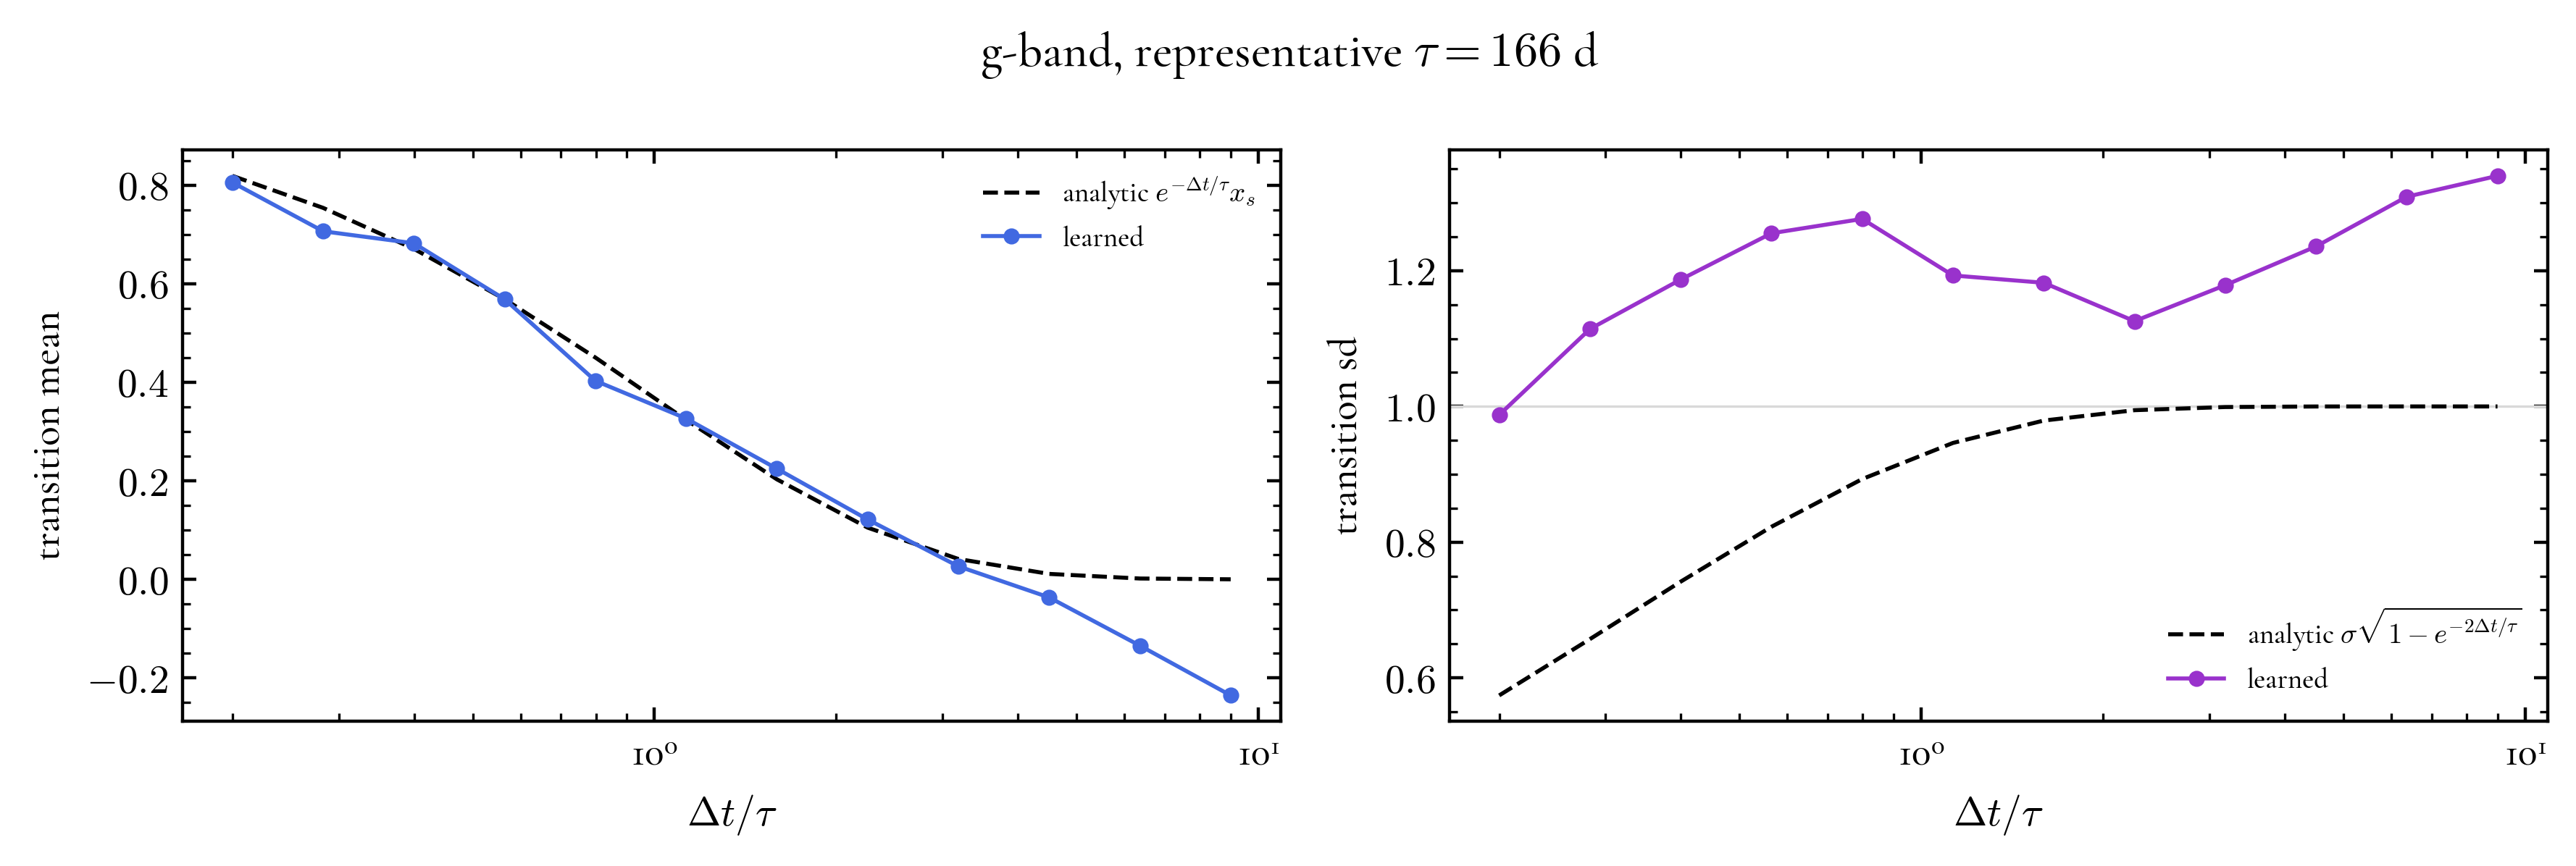

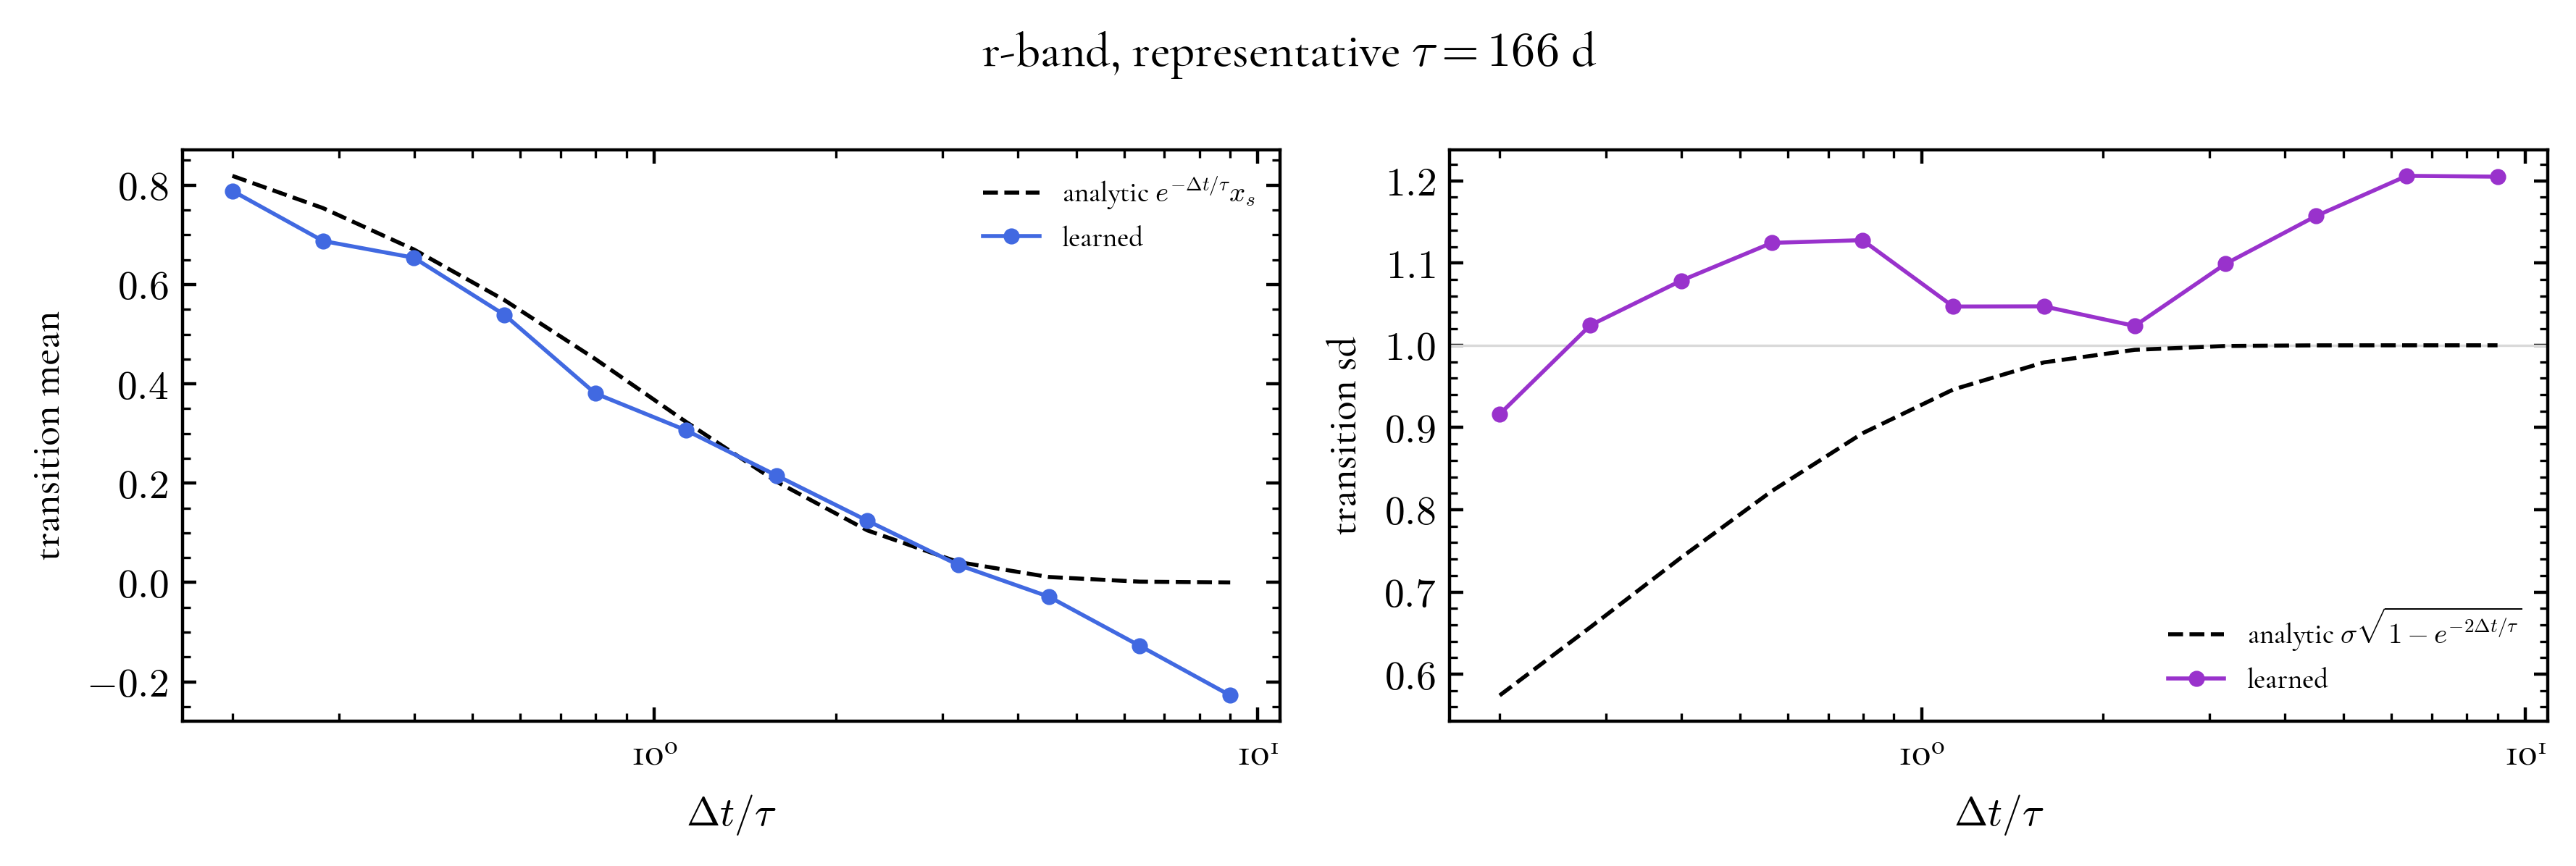

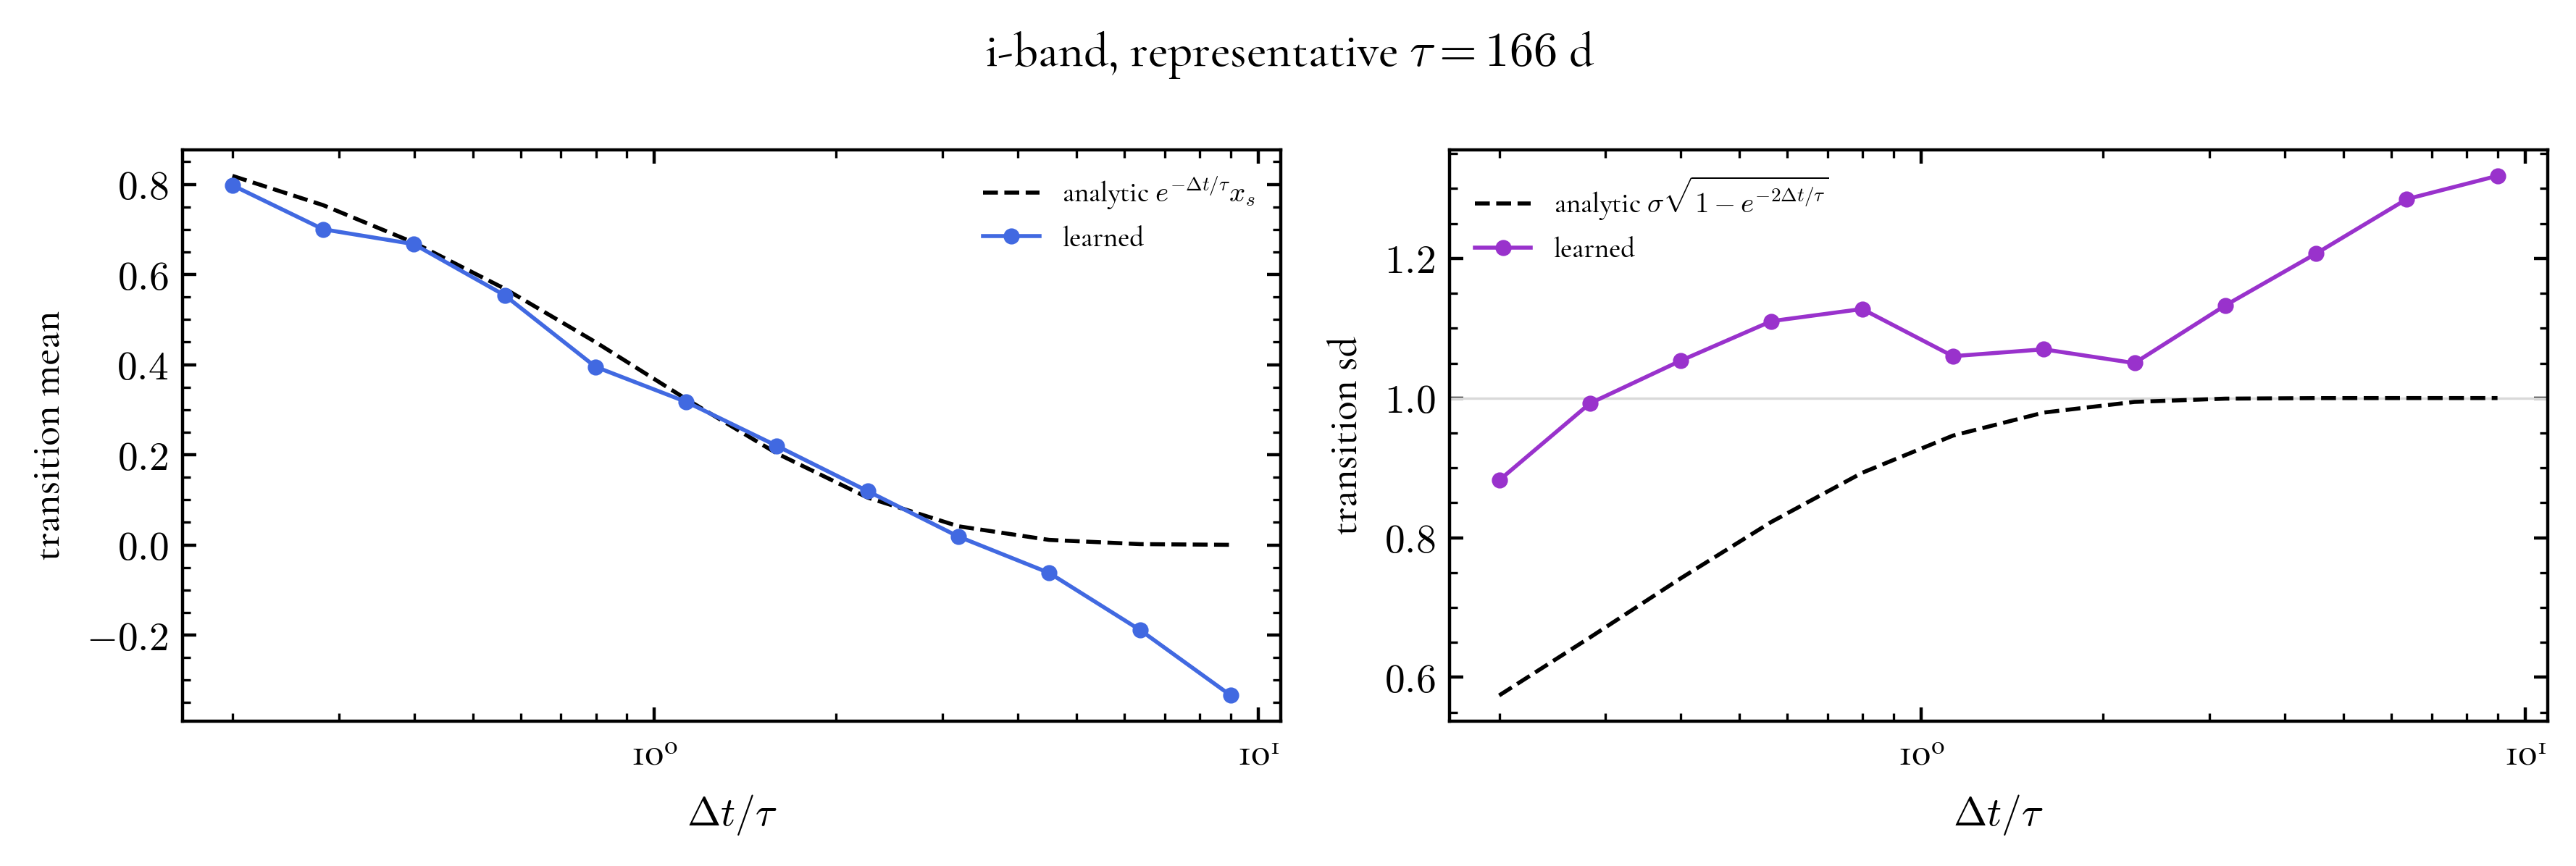

  sd   @ 9 tau : 1.32  (analytic 1.00)   -> must saturate at 1


In [ ]:
for band in ["g", "r", "i"]:
    r = results[band]
    D, flow = r["D"], r["flow"]
    i_ref = int(np.argmin(np.abs(np.asarray(D["tau"]) - np.median(D["tau"]))))
    tau_ref, sig_ref = float(D["tau"][i_ref]), float(D["sigma"][i_ref])
    dts = np.logspace(np.log10(0.2*tau_ref), np.log10(9*tau_ref), 12)
    lm, lv, tm, tv = checkTransition(flow, tau_ref, sig_ref, 1.0, dts, random.PRNGKey(2), n=4000)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3))
    ax[0].plot(dts/tau_ref, tm, "k--", label=r"analytic $e^{-\Delta t/\tau}x_s$")
    ax[0].plot(dts/tau_ref, lm, "o-", ms=3, color="royalblue", label="learned")
    ax[0].set_ylabel("transition mean")
    ax[1].axhline(sig_ref, color="0.85", lw=.6)
    ax[1].plot(dts/tau_ref, np.sqrt(tv), "k--", label=r"analytic $\sigma\sqrt{1-e^{-2\Delta t/\tau}}$")
    ax[1].plot(dts/tau_ref, np.sqrt(lv), "o-", ms=3, color="darkorchid", label="learned")
    ax[1].set_ylabel("transition sd")
    for a in ax: a.set_xscale("log"); a.set_xlabel(r"$\Delta t/\tau$"); a.legend(fontsize=7)
    fig.suptitle(f"{band}-band, representative $\\tau={tau_ref*D['t_scale']:.0f}$ d")
    plt.tight_layout(); plt.show()

    plt.savefig(f"/Users/anacecilialr/GitHub/MASS/MASS-Thesis/experiments/figures/LearnedTrans{band}.pdf")
print(f"  sd   @ 9 tau : {np.sqrt(lv[-1]):.2f}  (analytic {np.sqrt(tv[-1]):.2f})   -> must saturate at 1")

## 4. Gap filling, against the Bayes-optimal baseline

The DRW-GP is handed the **true** $\tau$ and $\sigma$, and the data were generated from exactly that
process, making it the optimal filler by construction. 

Filling a gap means conditioning on **both** endpoints, that is what a bridge is. The transition
alone conditions on the left endpoint only, which is forecasting: it drifts and its band widens
monotonically.

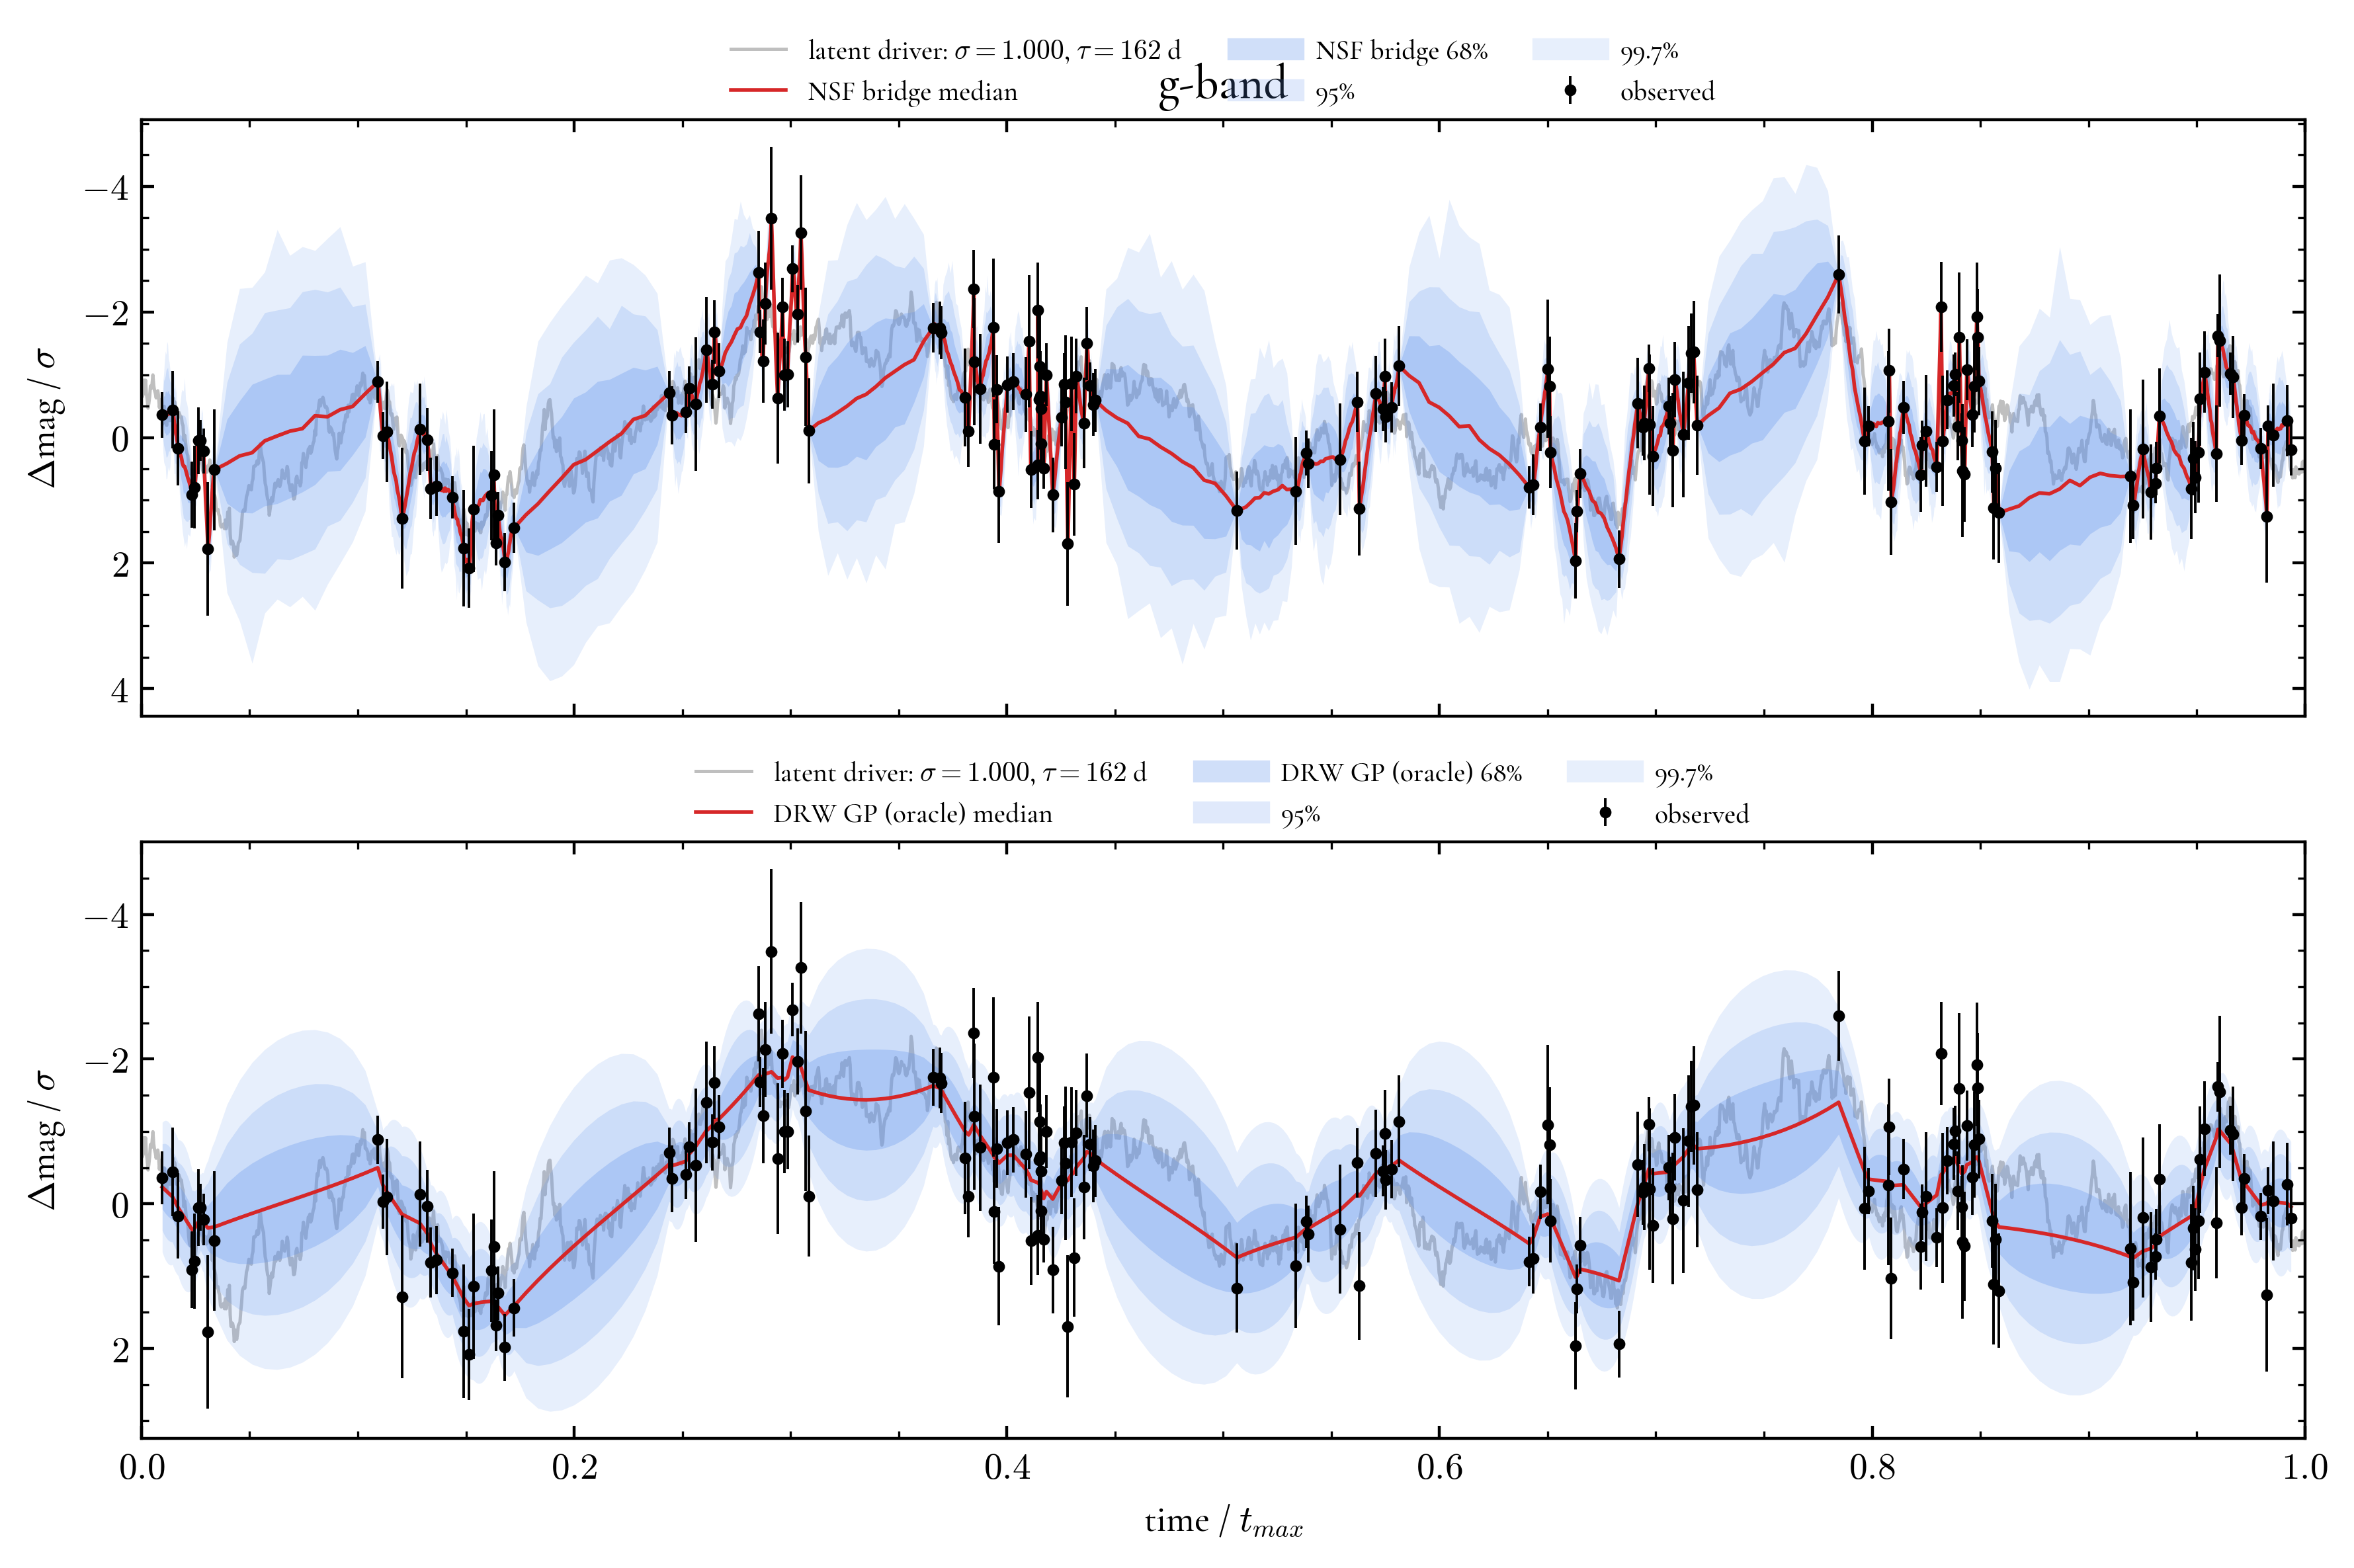

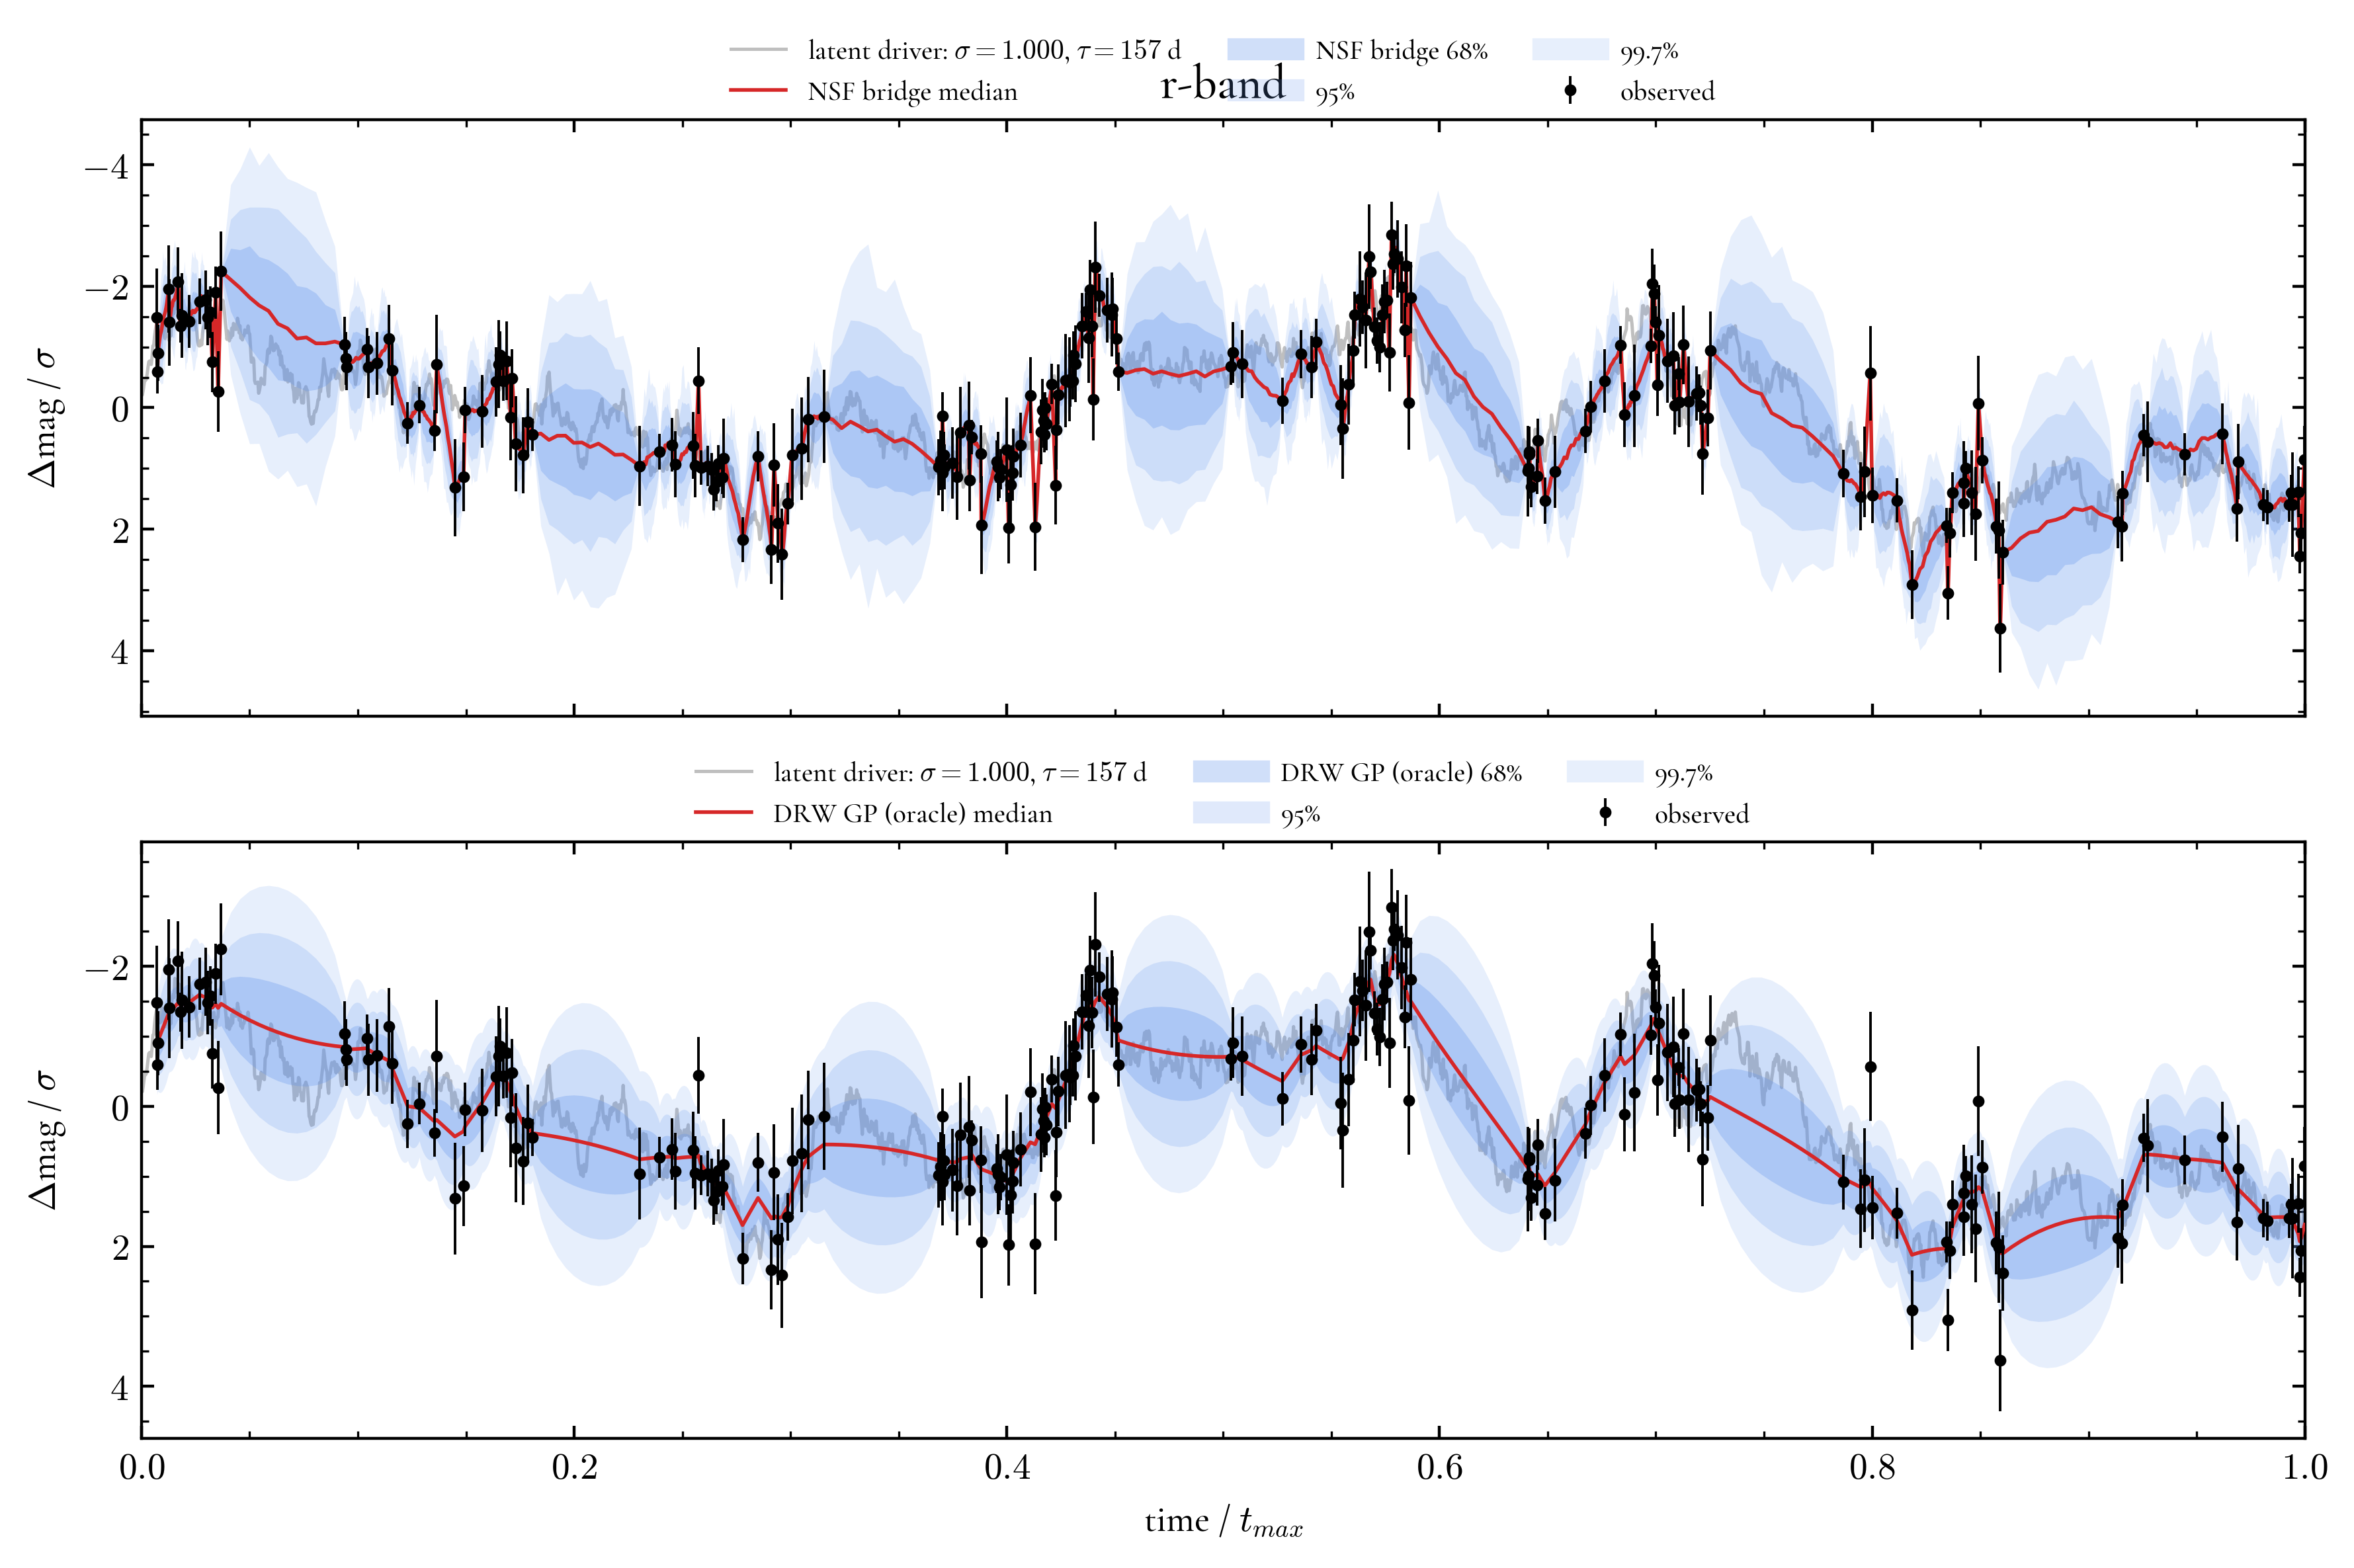

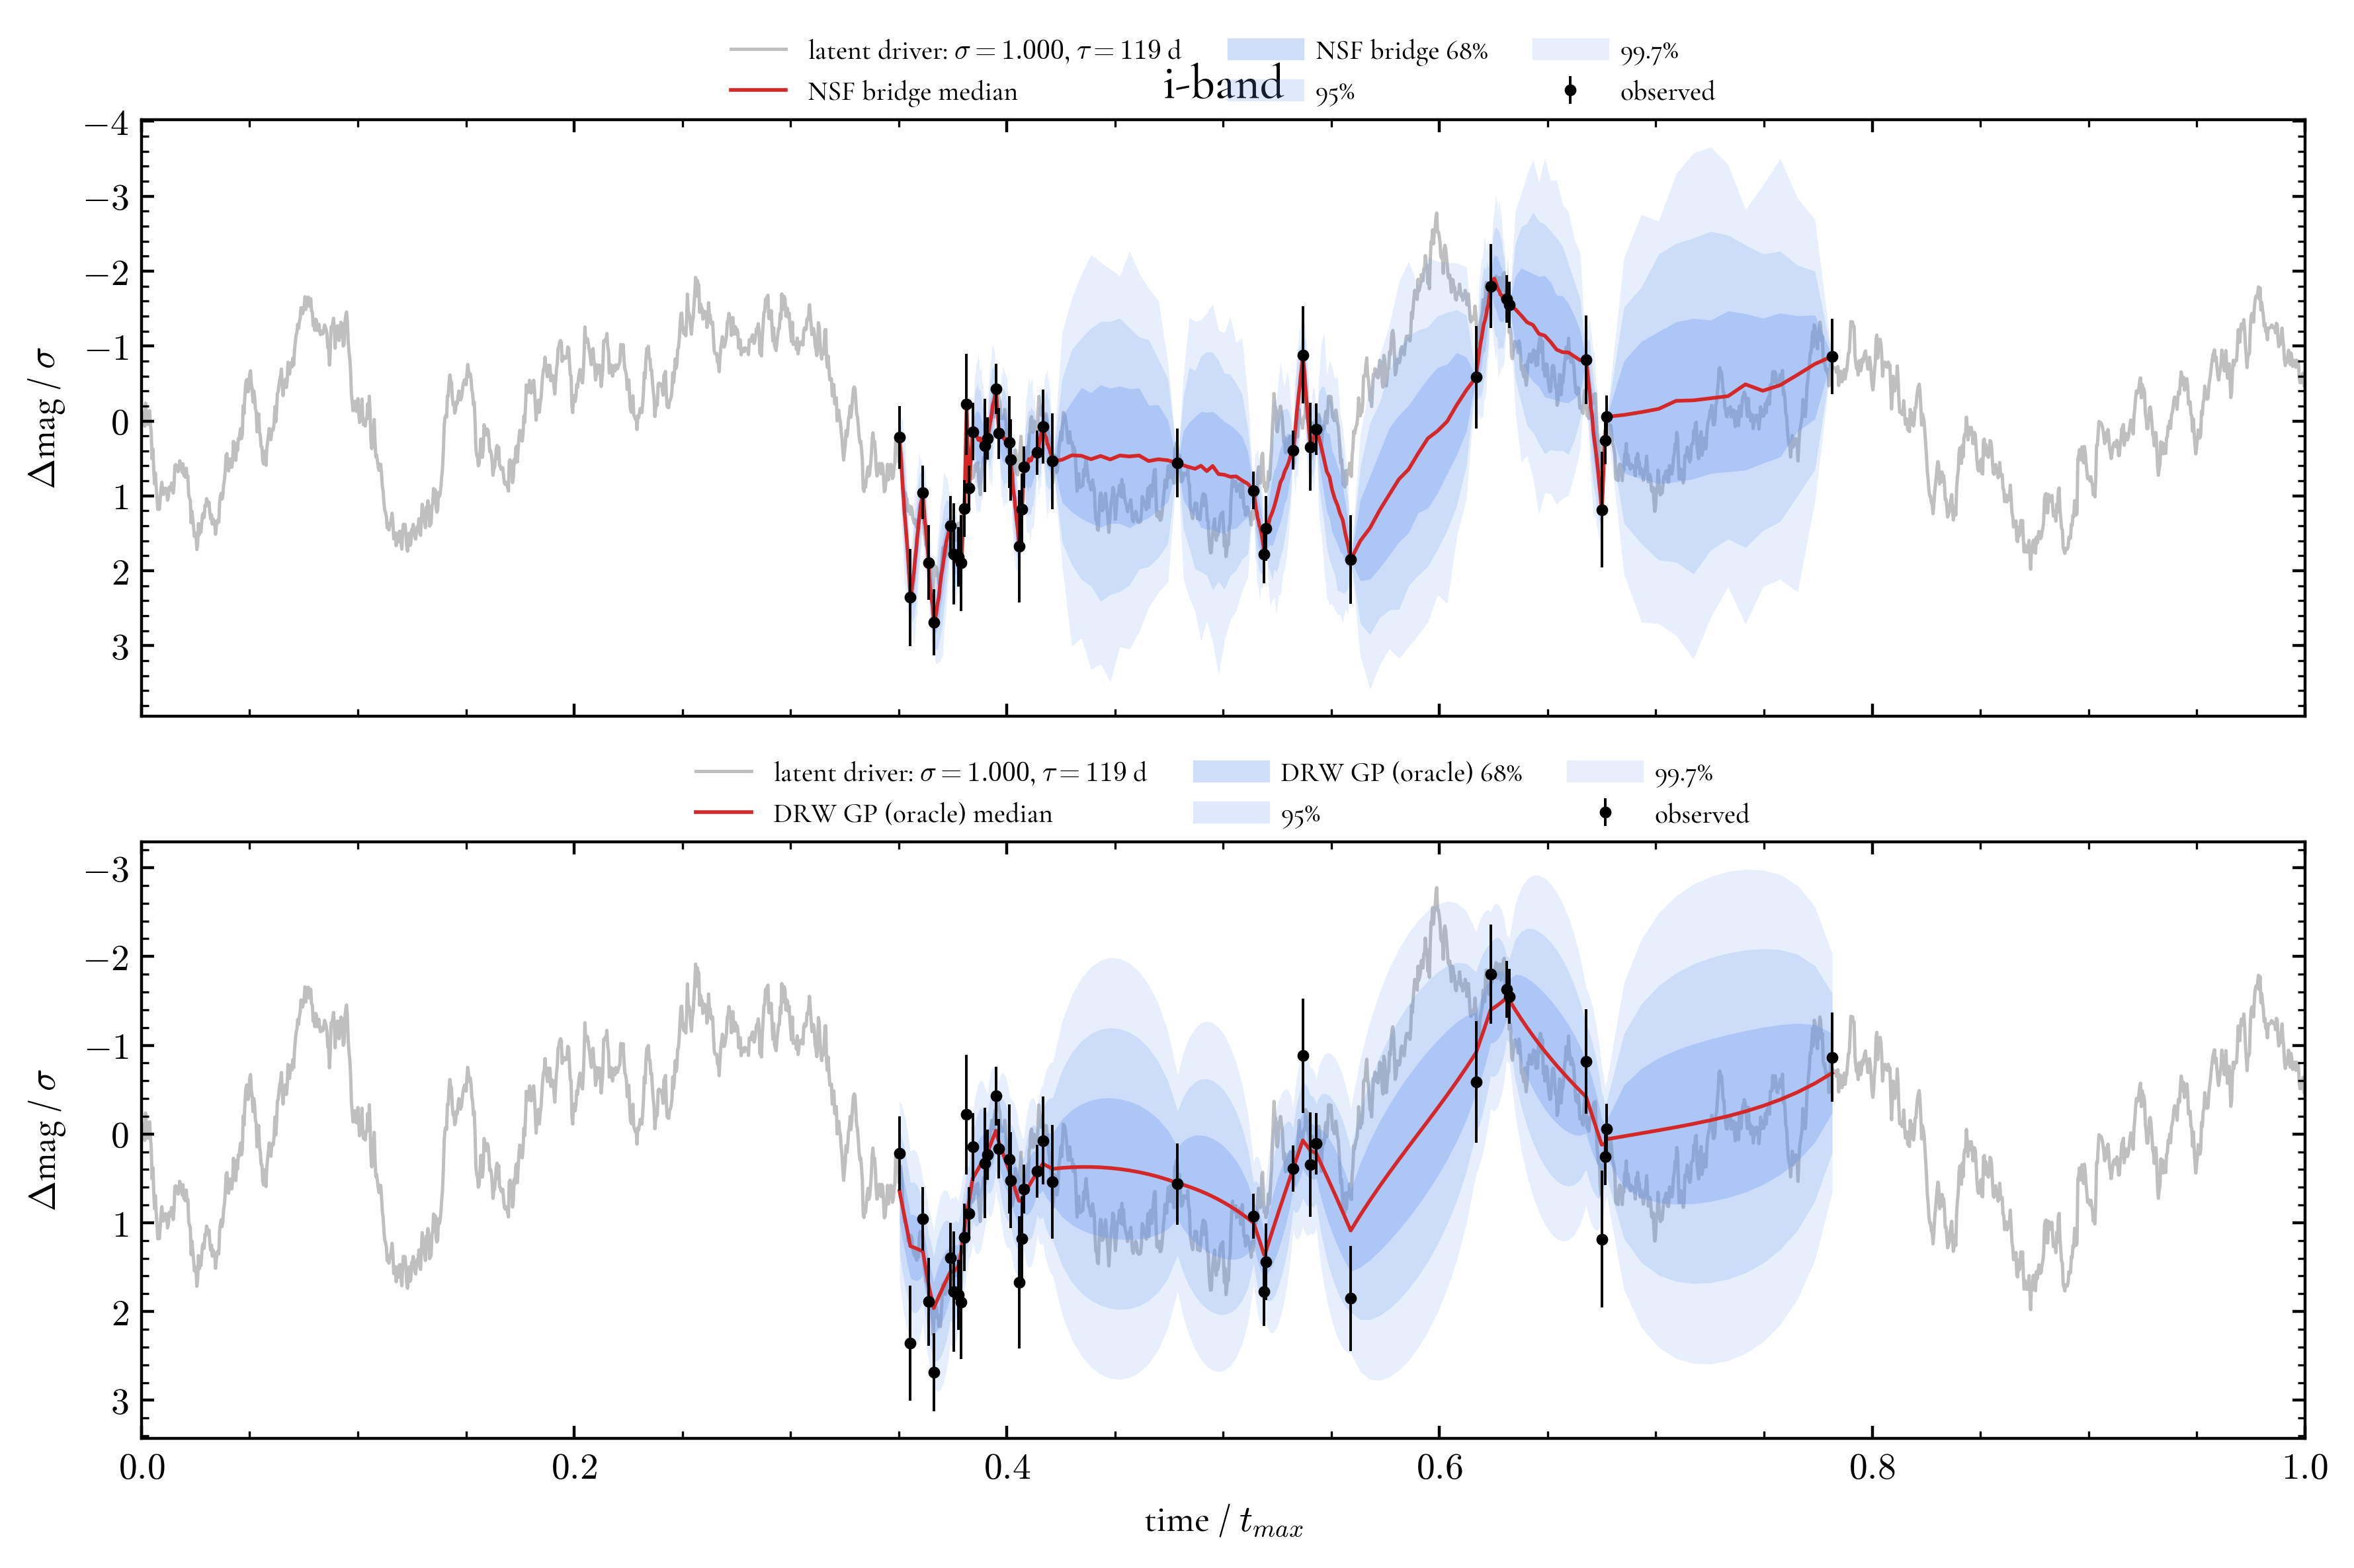

In [ ]:
for band in ["g", "r", "i"]:
    r = results[band]; V, bridge, D = r["V"], r["bridge"], r["D"]
    # pick a curve with a wide gap
    gapsize = [np.max(np.diff(np.asarray(V["t"][i])[V["mask"][i]])) / float(V["tau"][i])
               for i in range(len(V["t"]))]
    i = int(np.argsort(gapsize)[len(gapsize)//2])   # mediand curve

    m = np.asarray(V["mask"][i])
    t_o, y_o, e_o = np.asarray(V["t"][i])[m], np.asarray(V["y"][i])[m], np.asarray(V["yerr"][i])[m]
    t_tr, y_tr = np.asarray(V["t_true"]), np.asarray(V["y_true"][i])
    tau_i, sig_i = float(V["tau"][i]), float(V["sigma"][i])

    t_rec, s_rec = fillGaps(bridge, t_o, y_o, n_samples=800, grid_per_gap=12, seed=0)
    mu, sd = drwGPBaseline(t_o, y_o, e_o, t_rec, tau_i, sig_i)


    fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
    plotGapFill(t_tr, y_tr, t_o, y_o, e_o, t_rec, s_rec, ax=axes[0], label="NSF bridge",
                tau=tau_i, sigma=sig_i, t_scale=D["t_scale"])
    plotGapFill(t_tr, y_tr, t_o, y_o, e_o, t_rec, (mu, sd), ax=axes[1],
                label=r"DRW GP (oracle)", tau=tau_i, sigma=sig_i, t_scale=D["t_scale"])
    axes[0].set_title(f"{band}-band", fontsize=13); axes[0].set_xlabel("")
    plt.tight_layout(); plt.show()
    plt.savefig(f"/Users/anacecilialr/GitHub/MASS/MASS-Thesis/experiments/figures/FilledGap{band}.pdf")

## 5. Pooled error

In [6]:

print(f"{'band':6s}{'':10s}{'coverage@68% (med,16-84)':>28s}{'RMSE (med,16-84)':>24s}")
for band in ["g", "r", "i"]:
    res = results[band]["res"]
    for lab, ck, rk in [("NSF", "nsf_cov", "nsf_rmse"), ("GP", "gp_cov", "gp_rmse")]:
        cov = np.array([x[ck] for x in res]); rms = np.array([x[rk] for x in res])
        print(f"{band if lab=='NSF' else '':6s}{lab:10s}"
              f"{np.median(cov):.2f} [{np.percentile(cov,16):.2f}, {np.percentile(cov,84):.2f}]"
              f"      {np.median(rms):.3f} [{np.percentile(rms,16):.3f}, {np.percentile(rms,84):.3f}]")
    dr = np.array([x["nsf_rmse"] - x["gp_rmse"] for x in res])
    print(f"       -> NSF {100*np.median(dr)/np.median([x['gp_rmse'] for x in res]):+.0f}% vs Bayes-optimal\n")

band                coverage@68% (med,16-84)        RMSE (med,16-84)
g     NSF       0.31 [0.28, 0.35]      0.567 [0.533, 0.598]
      GP        0.68 [0.64, 0.72]      0.296 [0.265, 0.360]
       -> NSF +89% vs Bayes-optimal

r     NSF       0.33 [0.31, 0.37]      0.454 [0.427, 0.478]
      GP        0.69 [0.65, 0.72]      0.264 [0.226, 0.288]
       -> NSF +72% vs Bayes-optimal

i     NSF       0.42 [0.37, 0.47]      0.469 [0.428, 0.529]
      GP        0.67 [0.62, 0.72]      0.318 [0.275, 0.380]
       -> NSF +46% vs Bayes-optimal



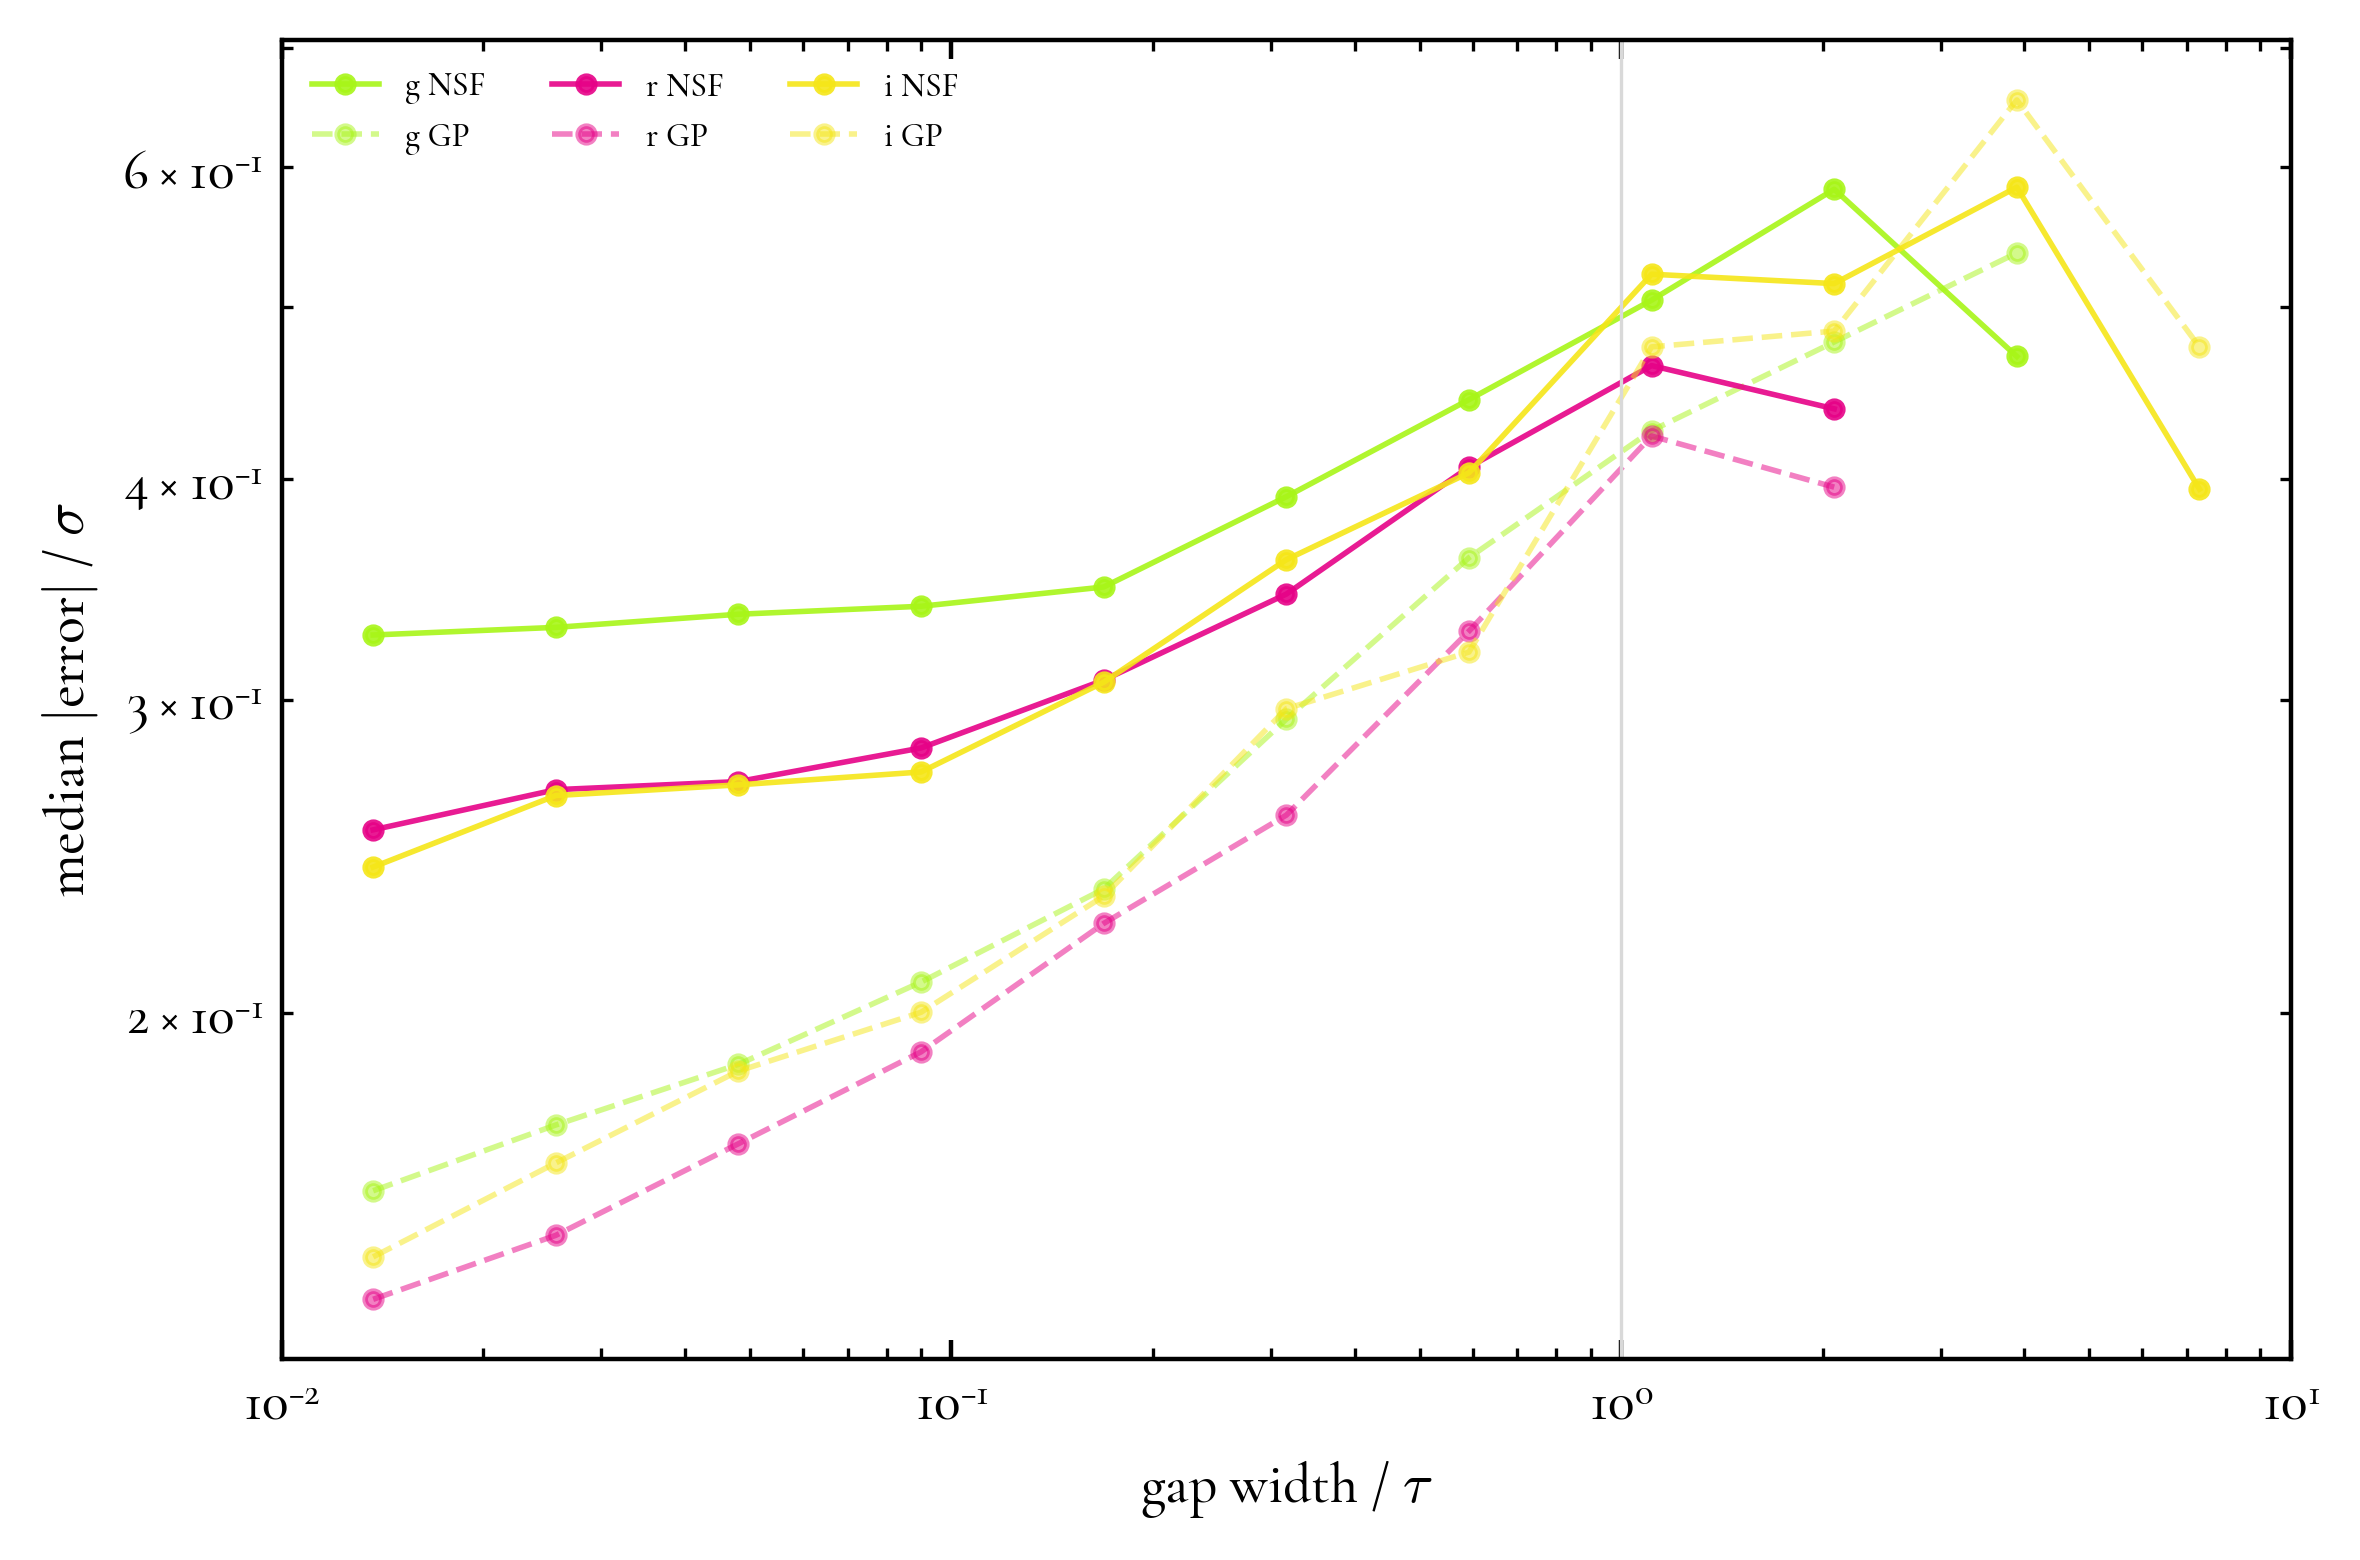

In [23]:

plt.figure(figsize=(6, 4))
band_col = {"g": "#a8f518", "r": "#e60287", "i": "#f5e618"}

for band in ["g", "r", "i"]:
    res = results[band]["res"]
    w   = np.concatenate([x["gap_tau"][x["interior"]] for x in res])
    enf = np.concatenate([np.abs(np.median(x["s_rec"],0) - x["y_ref"])[x["interior"]] for x in res])
    egp = np.concatenate([np.abs(x["mu"] - x["y_ref"])[x["interior"]] for x in res])

    bins = np.logspace(-2, 1, 12); cen = np.sqrt(bins[:-1]*bins[1:])   # extended to 10 tau 
    idx = np.digitize(w, bins) - 1
    for e, style, lab in [(enf, "-", f"{band} NSF"), (egp, "--", f"{band} GP")]:
        med = [np.median(e[idx==b]) if (idx==b).sum() > 20 else np.nan for b in range(len(cen))]
        plt.plot(cen, med, style, marker="o", ms=3, color=band_col[band],
                 label=lab, alpha=0.9 if style=="-" else 0.5)
plt.xscale("log"); plt.yscale("log"); plt.axvline(1.0, color="0.85", lw=.6)
plt.xlabel(r"gap width / $\tau$"); plt.ylabel(r"median $|$error$|$ / $\sigma$")
plt.legend(fontsize=6, ncol=3)
plt.tight_layout()
plt.savefig("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/experiments/figures/Error.pdf")
plt.show()

In the small gap regime the flow's error is consistently above the Gaussian Process (almost 2x), even when this is where the endpoints are very correlated and should be trivial to fill. The flow doesn't know that the observations it's training on are noisy (unlike the GP that knows all the truth and averages accordingly) so it cannot correct for that. It is a noise handling problem. 

As the gaps widen, both types of curves converge. This happens as the endpoints start getting more and more decorrelated so not even the GP can predict the future behaviour. 

## 6. Real ZTF Lightcurve

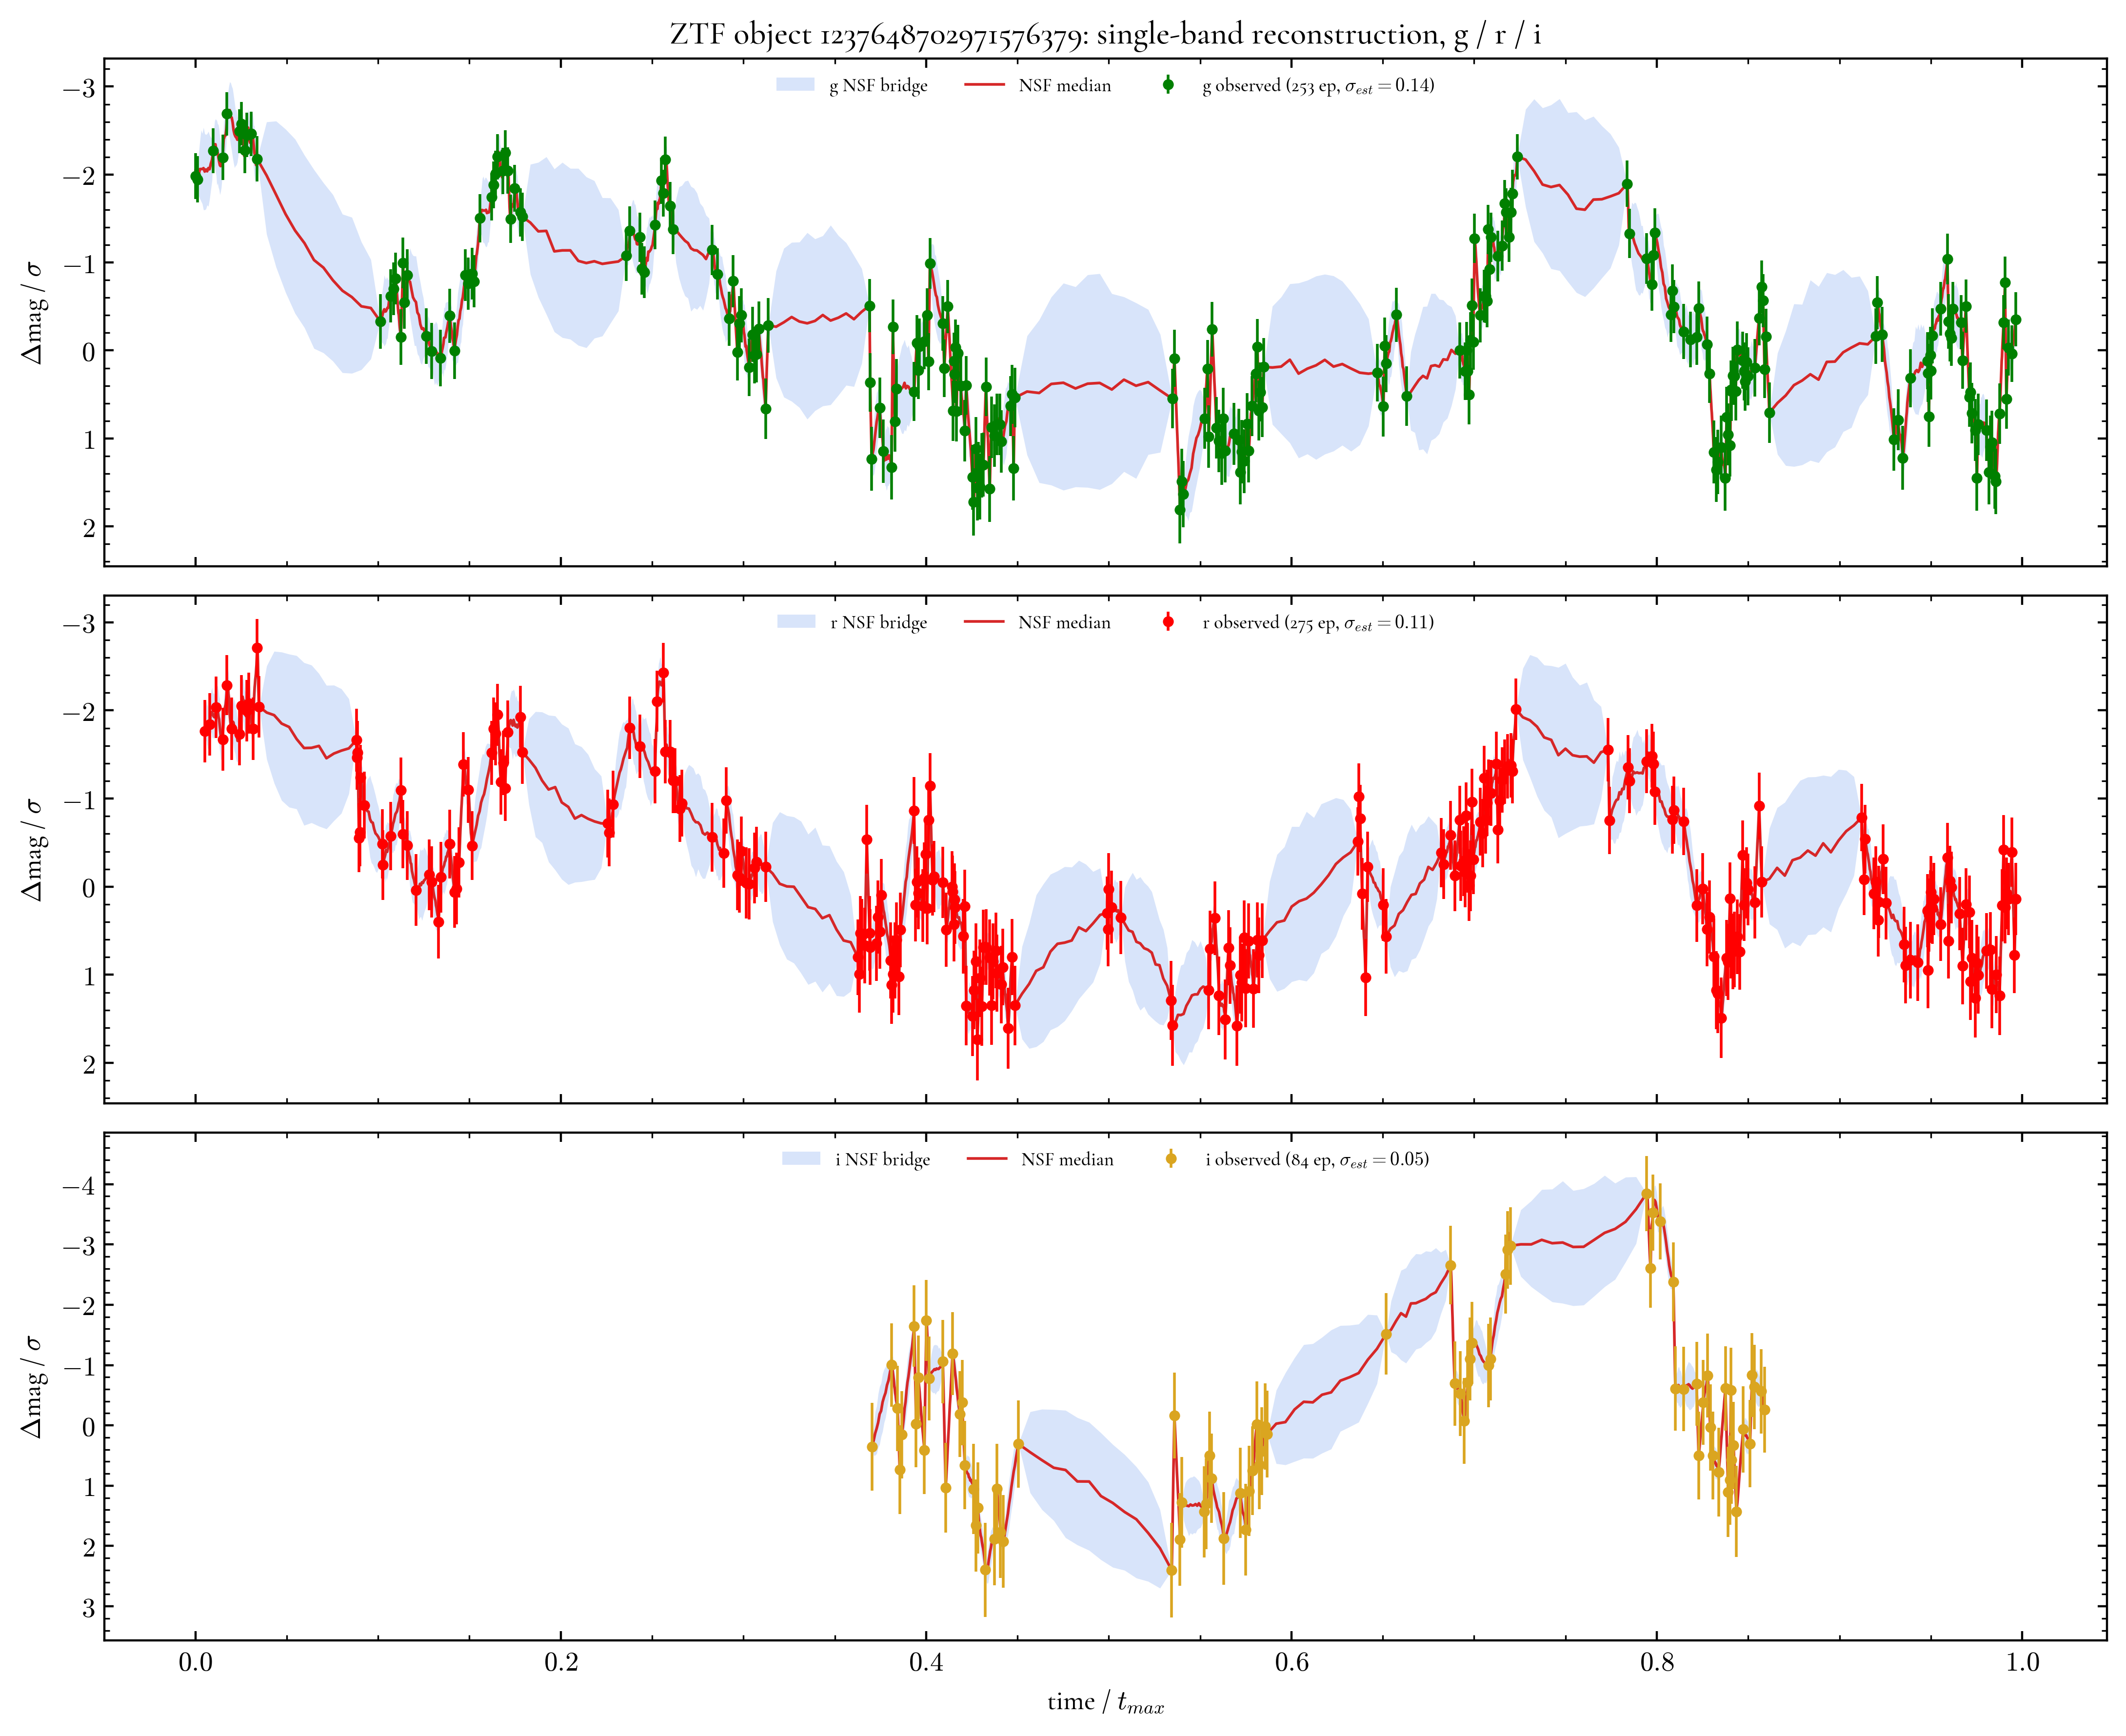

In [24]:
import pickle
from scipy.ndimage import median_filter

sample = pickle.load(open(f"/Users/anacecilialr/GitHub/MASS/MASS-Thesis/experiments/lightcurves/ztf_sample.pkl", "rb"))   # your 150 curves

# one r-band object

oid = list(sample)[10]

# shared baseline 
mjd0 = min(sample[oid]["lc"][b]["mjd"].min() for b in ["g", "r", "i"])

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
band_col = {"g": "green", "r": "red", "i": "goldenrod"}

for ax, band in zip(axes, ["g", "r", "i"]):
    d = sample[oid]["lc"][band]
    t_real = d["mjd"].values - mjd0                       
    y_real = d["mag"].values
    e_real = d["magerr"].values

    # drop isolated bad epochs
    order = np.argsort(t_real); ys = y_real[order]
    resid = ys - median_filter(ys, size=5)
    sc = 1.48 * np.median(np.abs(resid - np.median(resid)))
    keep_s = np.abs(resid) < 5 * sc
    keep = np.zeros(len(t_real), bool); keep[order] = keep_s
    t_real, y_real, e_real = t_real[keep], y_real[keep], e_real[keep]

    # normalize each by the estimated params
    robust = 1.48 * np.median(np.abs(y_real - np.median(y_real)))
    sigma_est = np.sqrt(max(robust**2 - np.median(e_real)**2, 0.01**2))
    t_scale = results[band]["D"]["t_scale"]
    t_n = t_real / t_scale
    y_n = (y_real - np.median(y_real)) / sigma_est
    e_n = e_real / sigma_est
    tau_n = float(np.median(results[band]["D"]["tau"]))

    # reconstruct 
    t_rec, s_rec = fillGaps(results[band]["bridge"], t_n, y_n,
                            n_samples=800, grid_per_gap=12, seed=0)
    lo, med, hi = np.percentile(s_rec, [16, 50, 84], axis=0)

    ax.fill_between(t_rec, lo, hi, color="cornflowerblue", alpha=0.25, lw=0, label=f"{band} NSF bridge")
    ax.plot(t_rec, med, color="tab:red", lw=1, label="NSF median")
    ax.errorbar(t_n, y_n, e_n, fmt="o", ms=3, color=band_col[band], capsize=0,
                label=f"{band} observed ({t_n.size} ep, $\\sigma_{{est}}={sigma_est:.2f}$)")
    ax.invert_yaxis(); ax.set_ylabel(r"$\Delta$mag / $\sigma$")
    ax.legend(fontsize=7, ncol=3, loc="upper center")

axes[2].set_xlabel(r"time / $t_{max}$")
axes[0].set_title(f"ZTF object {oid}: single-band reconstruction, g / r / i")
plt.tight_layout(); plt.show()

In [15]:
d = sample[oid]["lc"]["r"]
y = d["mag"].values
print(f"raw mag range: {y.min():.2f} to {y.max():.2f}, spread {y.max()-y.min():.2f}")
print(f"robust std (MAD): {1.48*np.median(np.abs(y-np.median(y))):.3f} mag")
print(f"points >0.4 mag from median: {np.sum(np.abs(y-np.median(y))>0.4)}")

raw mag range: 17.90 to 18.83, spread 0.94
robust std (MAD): 0.078 mag
points >0.4 mag from median: 7
